In [1]:
import plotly.express as px

In [3]:
max_performance_dic_ASU = {
    '1 GPU': 50,
    '2 GPUs': 140,
    '3 GPUs': 160, 
    '4 GPUs': 180, 
    '5 GPUs': 210, 
    '6 GPUs': 230, 
    '7 GPUs': 250,
    '8 GPUs': 260,
}

max_performance_dic_time = {
    '1 GPU': 306.37,
    '2 GPUs': 1998.74,
    '3 GPUs': 2957.33,
    '4 GPUs': 2726.10,
    '5 GPUs': 1731.79,
    '6 GPUs': 3440.59,
    '7 GPUs': 5099.87,
    '8 GPUs': 6000.34,
}

radius_dic = {
    '1 GPU': 42.384357,
    '2 GPUs': 68.961929,
    '3 GPUs': 70.162766,
    '4 GPUs': 70.770370,
    '5 GPUs': 70.221802,
    '6 GPUs': 73.267769,
    '7 GPUs': 68.748375,
    '8 GPUs': 68.748375,

}


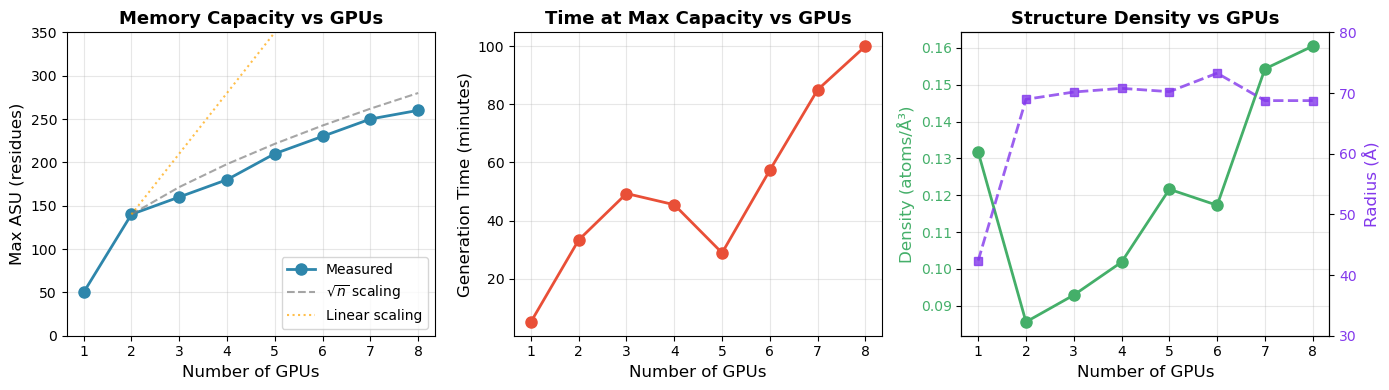

<Figure size 640x480 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import numpy as np


# Extract data
n_gpus = np.array([1, 2, 3, 4, 5, 6, 7, 8])
asu_max = np.array([max_performance_dic_ASU[f'{n} GPU' if n == 1 else f'{n} GPUs'] for n in n_gpus])
time_max = np.array([max_performance_dic_time[f'{n} GPU' if n == 1 else f'{n} GPUs'] for n in n_gpus])
radius = np.array([radius_dic[f'{n} GPU' if n == 1 else f'{n} GPUs'] for n in n_gpus])

# Derived quantities
tokens = asu_max * 60        # I = ASU × 60 chains
atoms = tokens * 14          # L ≈ 14 × I
volume = (4/3) * np.pi * radius**3  # Å³
density = atoms / volume     # atoms per Å³

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Max ASU vs GPUs
ax1 = axes[0]
ax1.plot(n_gpus, asu_max, 'o-', color='#2E86AB', linewidth=2, markersize=8, label='Measured')
sqrt_scaling = 140 * np.sqrt(n_gpus / 2)
ax1.plot(n_gpus[1:], sqrt_scaling[1:], '--', color='gray', alpha=0.7, label=r'$\sqrt{n}$ scaling')
linear_scaling = 140 * (n_gpus / 2)
ax1.plot(n_gpus[1:], linear_scaling[1:], ':', color='orange', alpha=0.7, label='Linear scaling')
ax1.set_xlabel('Number of GPUs', fontsize=12)
ax1.set_ylabel('Max ASU (residues)', fontsize=12)
ax1.set_title('Memory Capacity vs GPUs', fontsize=13, fontweight='bold')
ax1.set_xticks(n_gpus)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 350)

# Plot 2: Time vs GPUs (at max capacity)
ax2 = axes[1]
ax2.plot(n_gpus, time_max / 60, 'o-', color='#E94F37', linewidth=2, markersize=8)
ax2.set_xlabel('Number of GPUs', fontsize=12)
ax2.set_ylabel('Generation Time (minutes)', fontsize=12)
ax2.set_title('Time at Max Capacity vs GPUs', fontsize=13, fontweight='bold')
ax2.set_xticks(n_gpus)
ax2.grid(True, alpha=0.3)

# Plot 3: Density and Radius vs GPUs
ax3 = axes[2]
ax3.plot(n_gpus, density, 'o-', color='#44AF69', linewidth=2, markersize=8, label='Density')
ax3.set_xlabel('Number of GPUs', fontsize=12)
ax3.set_ylabel('Density (atoms/Å³)', fontsize=12, color='#44AF69')
ax3.set_title('Structure Density vs GPUs', fontsize=13, fontweight='bold')
ax3.set_xticks(n_gpus)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='y', labelcolor='#44AF69')

# Add radius on twin axis
ax3_twin = ax3.twinx()
ax3_twin.plot(n_gpus, radius, 's--', color='#8338EC', linewidth=2, markersize=6, alpha=0.8, label='Radius')
ax3_twin.set_ylabel('Radius (Å)', fontsize=12, color='#8338EC')
ax3_twin.tick_params(axis='y', labelcolor='#8338EC')
ax3_twin.set_ylim(30, 80)

plt.tight_layout()
plt.show()




from pathlib import Path
output_path = Path('/Users/kebl8661/remote/foundry/plotting/scaling_analysis.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
